## Task 1 - Identifying the Prediction Target

In [4]:
import pandas as pd

df = pd.read_csv('bank-additional.csv', sep=';')
print(df.columns.tolist())
print(df['y'].value_counts())
print(df['y'].dtype)

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
y
no     3668
yes     451
Name: count, dtype: int64
str


### Target Variable: 'y'
The column 'y' is the prediction target which indicates if the client subscribed to a term deposit or not, ('yes) or ('no). This is related to the advertising goal of the campaign, which is to identify clients who are likely to convert.

## Task 2 - Data Loading and Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank-additional.csv', sep=';')

print("Dataset Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n Data Types")
print(df.dtypes)

print("\nData Descriptions")
print(df.describe())

Dataset Shape
Rows: 4119, Columns: 21

 Data Types
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Data Descriptions
               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   


The dataset has 4,119 rows and 21 columns: 10 are numerical and 11 are categorical, including the target 'y'.

In [3]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [5]:
print("== Target Variable Distribution ==")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== Target Variable Distribution ===
y
no     3668
yes     451
Name: count, dtype: int64
y
no     89.05%
yes    10.95%
Name: proportion, dtype: str


**Target Imbalance:** 89.1% say 'no' and 10.9% say 'yes'. This is certainly a significant imbalance that will need to be addressed on further steps.

In [6]:
print("Explicit Missing Values (NaN)")
print(df.isnull().sum())

print("Implicit Missing Values ('unknown')")
for col in categorical_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"{col}: {n} unknowns ({n/len(df)*100:.2f}%)")

Explicit Missing Values (NaN)
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Implicit Missing Values ('unknown')
job: 39 unknowns (0.95%)
marital: 11 unknowns (0.27%)
education: 167 unknowns (4.05%)
default: 803 unknowns (19.50%)
housing: 105 unknowns (2.55%)
loan: 105 unknowns (2.55%)


**NaN Values:** No explicit NaN values are present, but many categorical columns contain "unknown" entries which propably act as implicit missing values. These are: job`, `marital`, `education`, `default`, `housing`, and `loan`

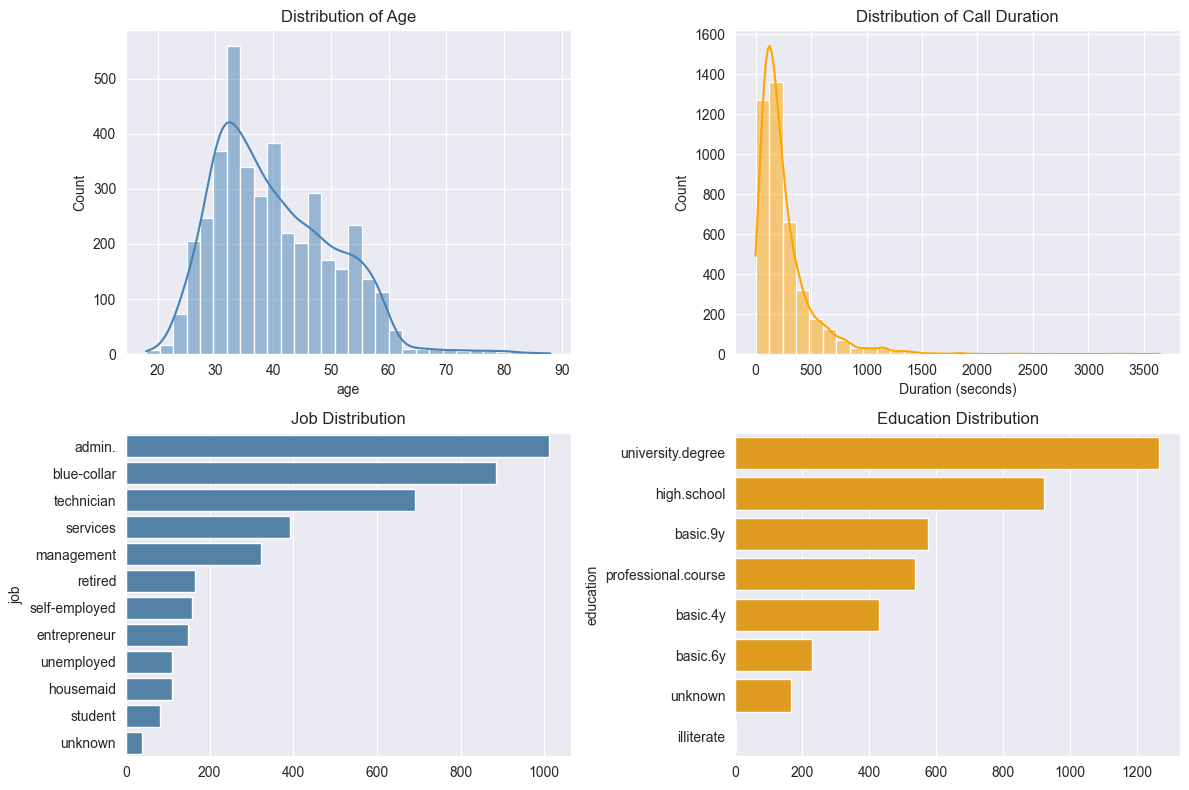

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Numerical: age
sns.histplot(df['age'], bins=30, ax=axes[0,0], color='steelblue', kde=True)
axes[0,0].set_title('Distribution of Age')

# Numerical: duration
sns.histplot(df['duration'], bins=30, ax=axes[0,1], color='orange', kde=True)
axes[0,1].set_title('Distribution of Call Duration')
axes[0,1].set_xlabel('Duration (seconds)')

# Categorical: job
job_counts = df['job'].value_counts()
sns.barplot(x=job_counts.values, y=job_counts.index, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Job Distribution')

# Categorical: education
edu_counts = df['education'].value_counts()
sns.barplot(x=edu_counts.values, y=edu_counts.index, ax=axes[1,1], color='orange')
axes[1,1].set_title('Education Distribution')

plt.tight_layout()
plt.show()

**`duration`** needs special attention because it represents the call duration in seconds, which is only known after the call ends. This means it is not available at true prediction time and creates risk of data leakage if kept as a feature.
Also `duration` as we can see is heavily right-skewed. Most calls short and few are very long.
**`age`** is also right-skewed with most clients between 25-60.
(These graphs were made using the help of AI)

## Task 3 - Data Splitting

In [11]:
from sklearn.model_selection import train_test_split

#Separate features and target
X = df.drop(columns=['y'])
y = df['y']

#First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: temp → 50% val, 50% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("== Split Sizes ==")
print(f"Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.1f}%)")

== Split Sizes ==
Training set: 3295 rows (80.0%)
Validation set: 412 rows (10.0%)
Test set:       412 rows (10.0%)


### Annotations
**1. Proportions** I used an 80/10/10 (train/val/test), and here is why:
- The training set needs to be large enough for the model to learn but not memorize, so learn reliably.
- Validation (10%) is for tuning decisions during the pipeline
- Test (10%) is held out entirely until the final evaluation.

**2. Why stratify?**
I used stratification to make sure each split has the same class distribution as the original set. In this particular case, since there is only around 11% of positive example, a random split could produce a validation or test set with very to no 'yes' cases. This would then make the evaluation unreliable.

**3. Why split before any preprocessing?**
Only training data should be accessed by any transformation that learns parameters from data, such as fitting encoders, fitting scalers, or computing methods for imputation. By splitting first, data leakage is avoided and validation and test sets are kept totally hidden.

**4. Example of incorrect ordering:**
If I scaled the entire dataset before splitting, the scaler would compute the mean and standard deviation using the test set values. The model would then be evaluated on data it has indirectly already seen. This would produce optimistic biased metrics.



## Task 4 - Managing Missing Values

In [12]:
print("== Explicit Missing Values (NaN) ==")
print(X_train.isnull().sum())

=== Explicit Missing Values (NaN) ===
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64


**Explicit Missing Values:**
No NaN values are present in the raw dataset.

In [13]:
print("== Implicit Missing Values in Training Set ==")
for col in X_train.select_dtypes(include=['object', 'str']).columns:
    n = (X_train[col] == 'unknown').sum()
    if n > 0:
        pct = n / len(X_train) * 100
        print(f"{col}: {n} unknowns ({pct:.2f}%)")

== Implicit Missing Values in Training Set ==
job: 28 unknowns (0.85%)
marital: 7 unknowns (0.21%)
education: 129 unknowns (3.92%)
default: 663 unknowns (20.12%)
housing: 78 unknowns (2.37%)
loan: 78 unknowns (2.37%)


**Implicit Missing Values:**
- As mentioned above, there are several categorical columns which contain 'unknown' entries. These are: `job`, `marital`, `education`, `default`, `housing`, `loan`. These should be treated as a separate category rather than imputing, because the fact that a client decided not to give certain information may be predictive of behavior.


In [14]:
print("=== Value counts for pdays ===")
print(X_train['pdays'].value_counts().head(10))

=== Value counts for pdays ===
pdays
999    3160
3        44
6        38
4        13
7         8
10        6
12        5
2         3
18        2
0         2
Name: count, dtype: int64


**Sentinel Value**
- `pdays = 999` is a sentinel value. This means the client was never previously contacted. It is not a real number of days, so it can be replaced with NaN and impute using the median of the training set. And the median is used rather than mean because the distribution is skewed.

In [15]:
# Replace 999 with NaN to make the missingness explicit, then its impute with median
import numpy as np

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train['pdays'] = X_train['pdays'].replace(999, np.nan)
X_val['pdays'] = X_val['pdays'].replace(999, np.nan)
X_test['pdays'] = X_test['pdays'].replace(999, np.nan)

# Fit median on training set only
pdays_median = X_train['pdays'].median()
print(f"pdays median (training set): {pdays_median}")

X_train['pdays'] = X_train['pdays'].fillna(pdays_median)
X_val['pdays'] = X_val['pdays'].fillna(pdays_median)
X_test['pdays'] = X_test['pdays'].fillna(pdays_median)

pdays median (training set): 6.0


**Why fit imputation on training only?**

Calculating the median on the complete dataset would result in the training set mistakenly including information from the validation and test sets, leading to a type of data leakage. Before applying any imputation parameters to val/test, they must all be learned completely from the training set.

In [16]:
unknown_cols = []
for col in X_train.select_dtypes(include=['object', 'str']).columns:
    n = (X_train[col] == 'unknown').sum()
    if n > 0:
        unknown_cols.append(col)

print("Columns with 'unknown' kept as separate category:", unknown_cols)


Columns with 'unknown' kept as separate category: ['job', 'marital', 'education', 'default', 'housing', 'loan']


**Handling `'unknown'` in Categorical Columns**

Instead of imputing the most frequent value to categorical columns with `'unknown'` entries, I decided to keep `'unknown'` as a separate category. This is for two reasons:
1. A predictive signal may be carried by missingness.
A client with an average job or no default is not the same as one who decided not to reveal their credit default status or type of employment. These clients may act consistently differently from those who responded, therefore the act of keeping information is informative. This indicator would be completely destroyed if the mode were substituted for `'unknown'`.
2. The missing-at-random assumption cannot be verified.
Only when the data is missing completely at random (MCAR) is imputation using the mode safe. Since there isn't much evidence to support that, it is more wise and accurate to classify `'unknown'` as a separate category.

By doing so, we are explicitly telling the model that "unknown" is a meaningful state that is different from any known category, which is a **modeling decision** rather than simply a data cleaning step.